In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import sys, os
sys.path.append("../../src/")


import scipy.stats as stats
from tqdm import tqdm
from baseline_network import BaselineNetwork

In [3]:
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'

In [4]:
save_loc_general = "../../results/full_network/1.1 feedforward - 3 inh levels/"
if not os.path.exists(save_loc_general):
    os.makedirs(save_loc_general)

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:699: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
100%|██████████| 840/840 [00:47<00:00, 17.74it/s]
/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:721: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:759: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
days: 100%|██████████| 28/28 [00:42<00:00,  1.52s/it]
/Users/divyansh/Library/CloudSto

TimeoutError: [Errno 60] Operation timed out: '../../results/full_network/1.1 feedforward - 3 inh levels/inh_scale_0.3/population_activity_evolution_theta_90.0.gif'

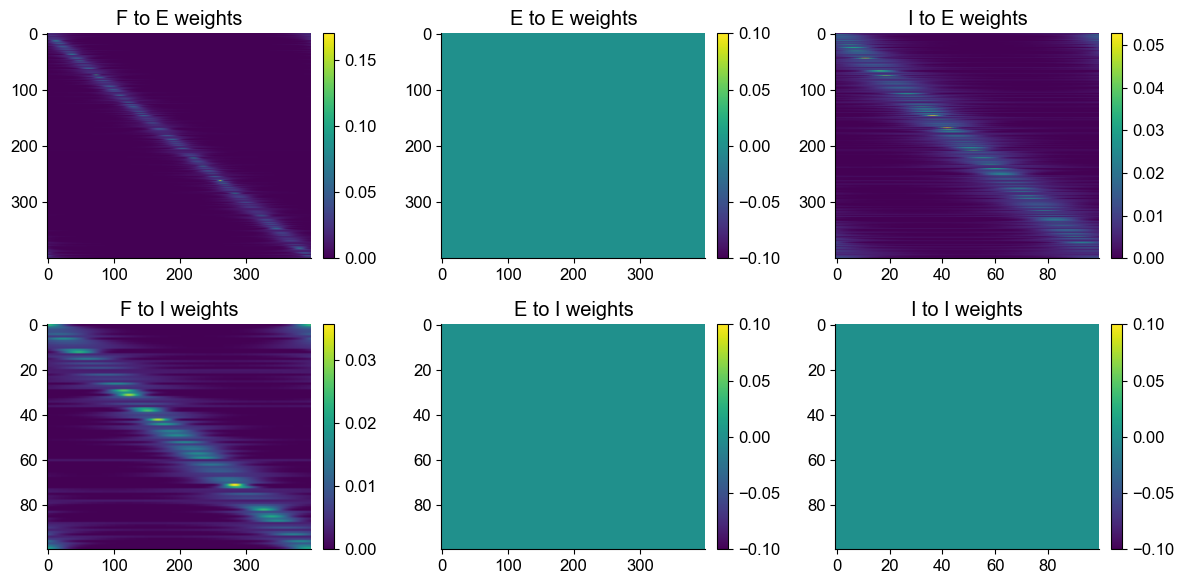

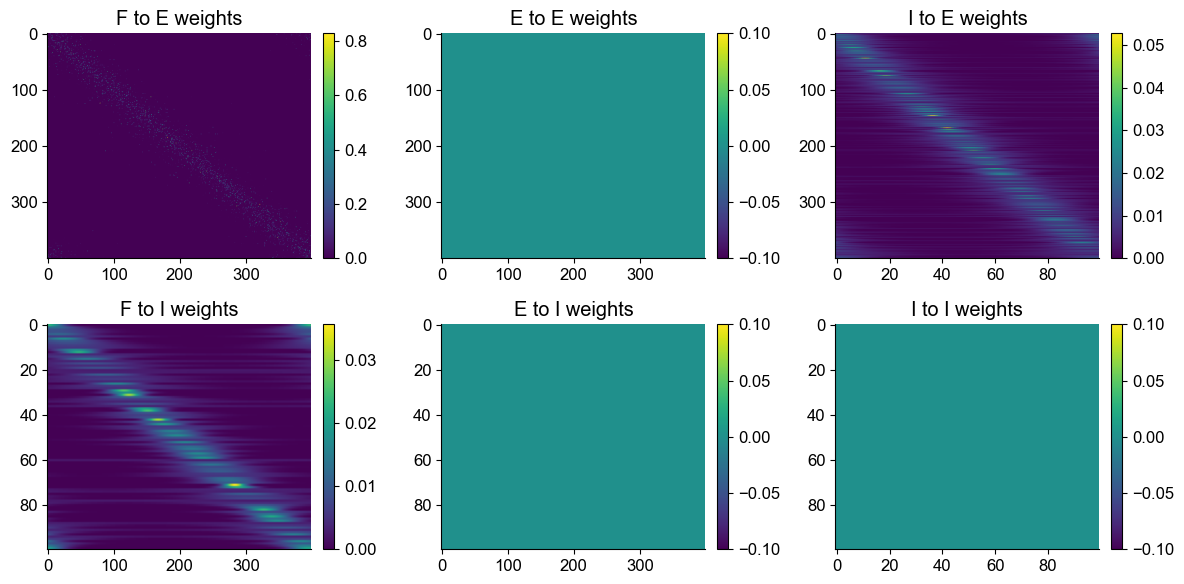

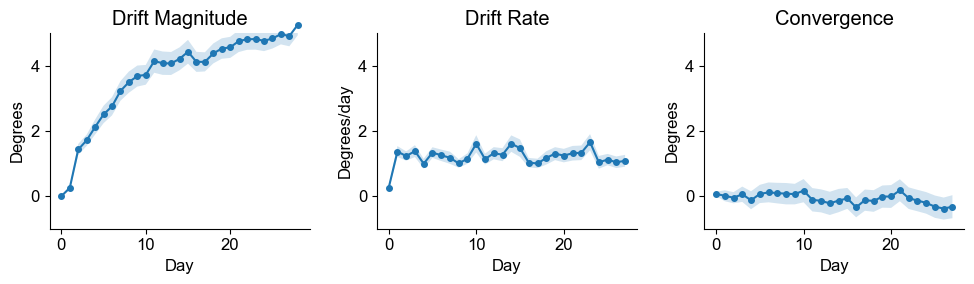

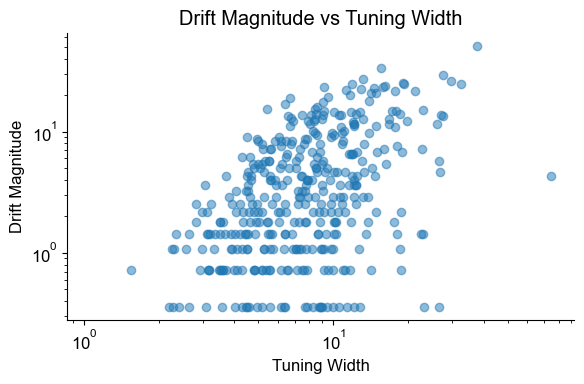

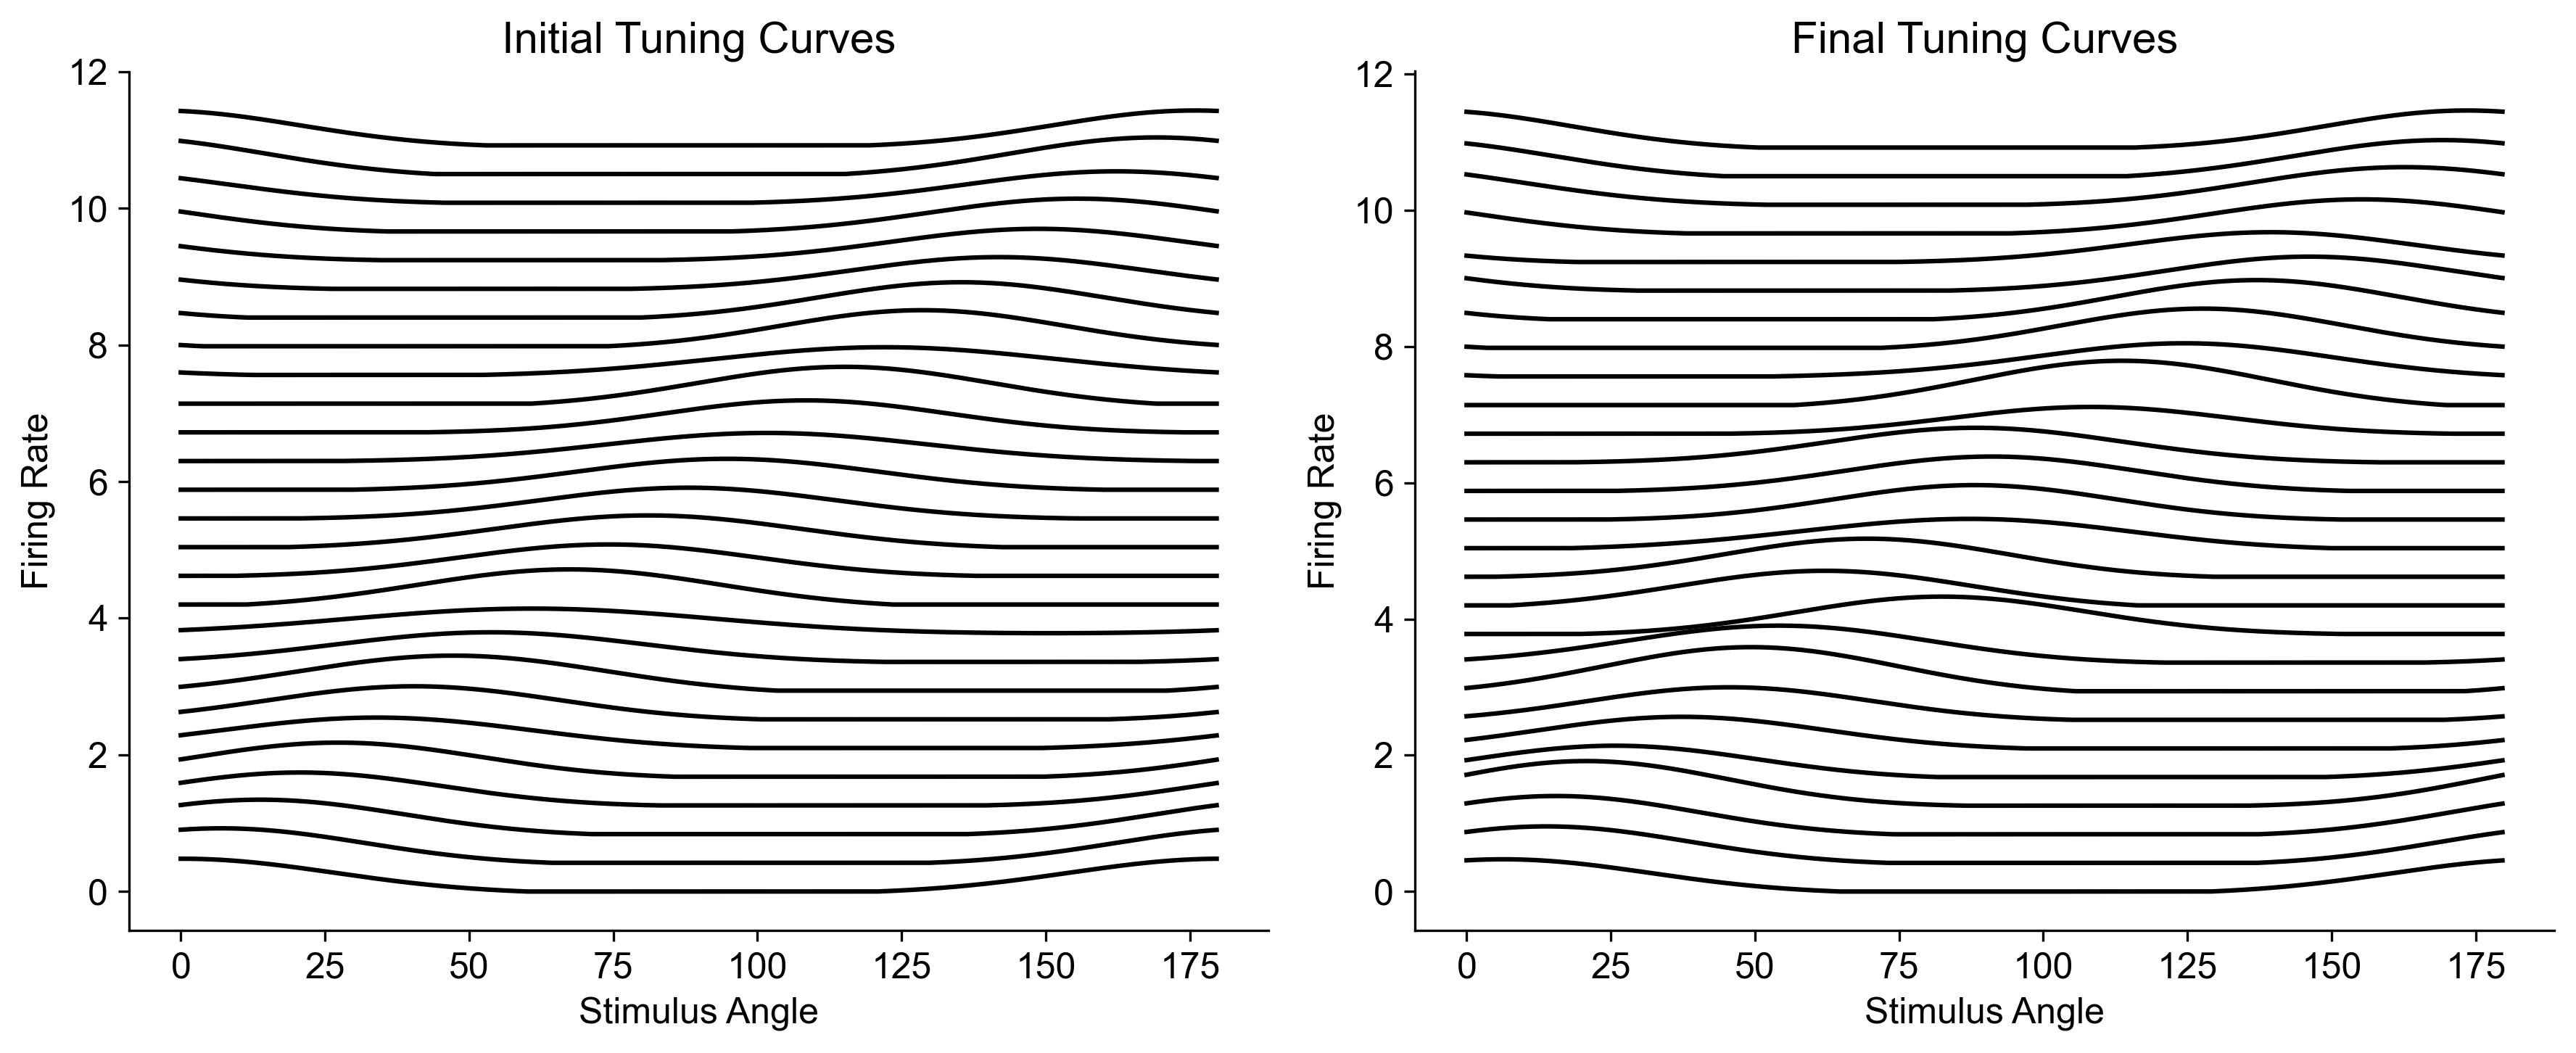

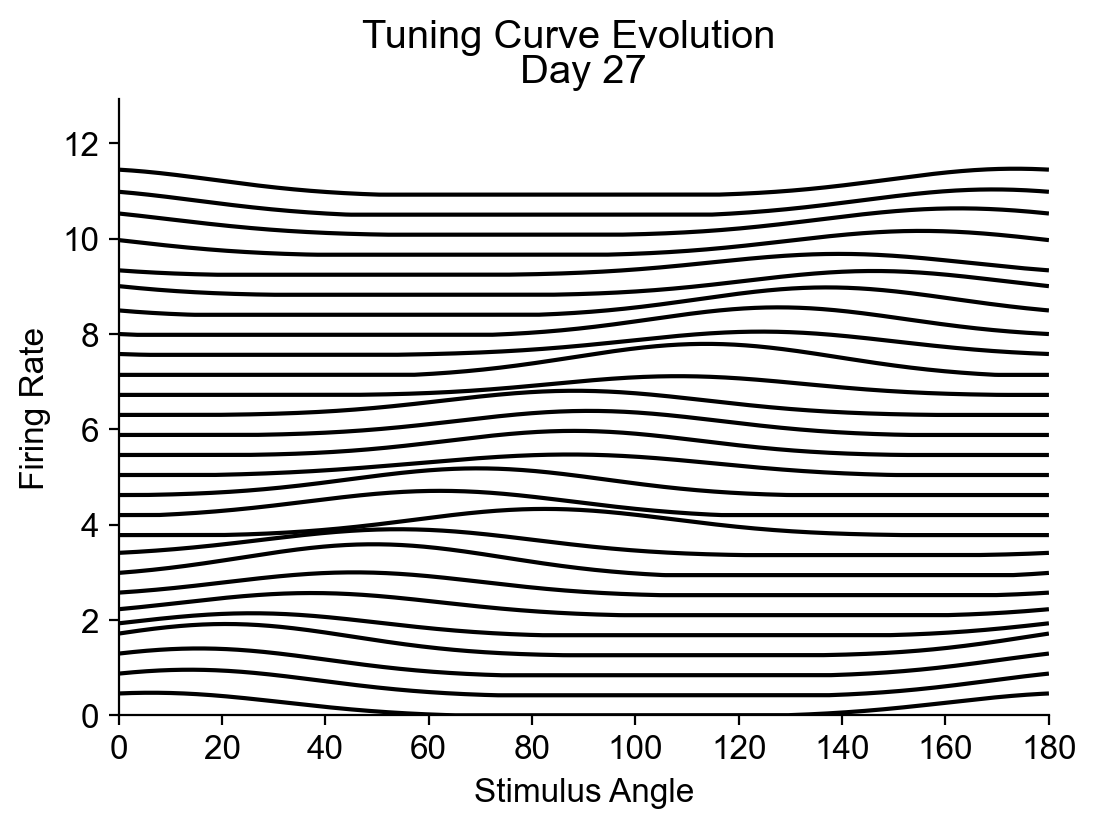

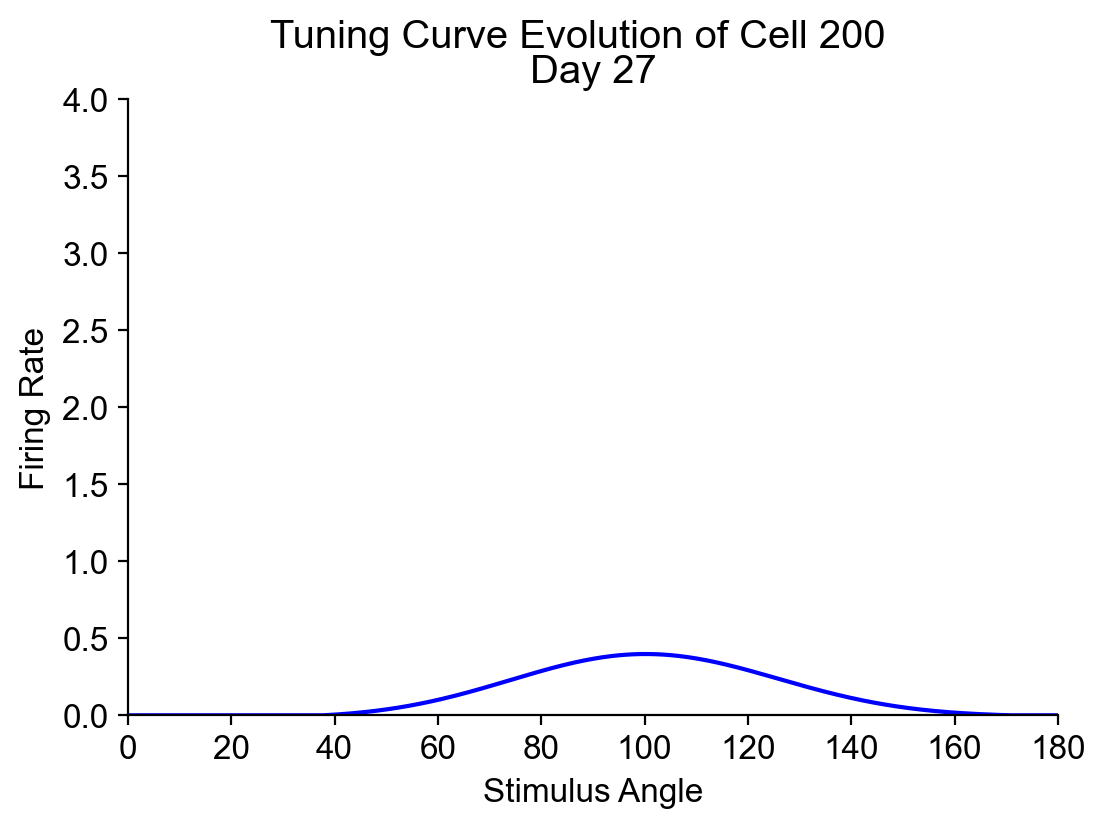

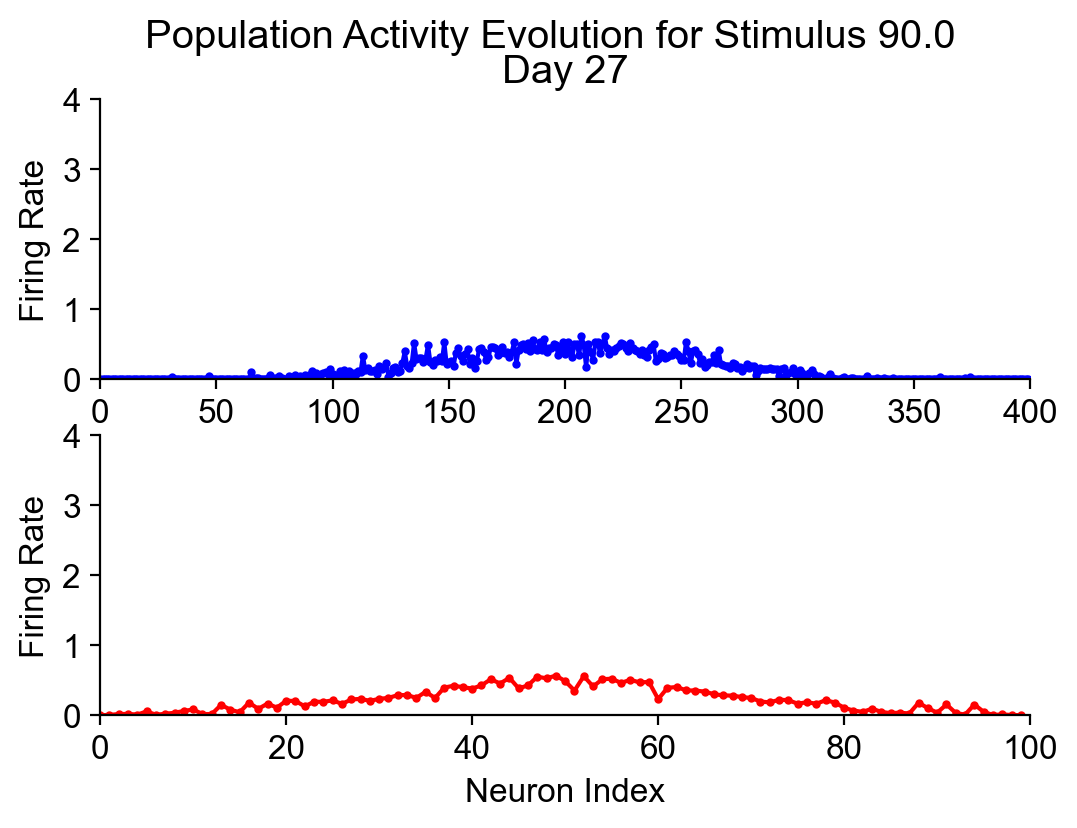

In [5]:
net_inh_1 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.3, 
                      save_location=save_loc_general + "inh_scale_0.3/")
net_inh_1.run_analysis(save_results=True)

net_inh_2 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.6, 
                      save_location=save_loc_general + "inh_scale_0.6/")
net_inh_2.run_analysis(save_results=True)

net_inh_3 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.9,
                      save_location=save_loc_general + "inh_scale_0.9/")
net_inh_3.run_analysis(save_results=True)

In [ ]:
net_inh_1 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.3, train_sigma=30)
net_inh_1.run()

net_inh_2 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.6, train_sigma=30)
net_inh_2.run()

net_inh_3 = BaselineNetwork(inh_type="co-tuned", E_to_E="off", E_to_I="off", I_to_I="off",
                      plasticity_E_to_E="off", plasticity_E_to_I="off", plasticity_I_to_E="off", plasticity_I_to_I="off",
                      norm=True, set_seed=True, seed=42, 
                      inh_scale=0.9, train_sigma=30)
net_inh_3.run()

100%|██████████| 840/840 [00:57<00:00, 14.52it/s]


In [ ]:
drift_mag_1, drift_rate_1, convergence_1 = net_inh_1.get_drift_metrics()
drift_mag_2, drift_rate_2, convergence_2 = net_inh_2.get_drift_metrics()
drift_mag_3, drift_rate_3, convergence_3 = net_inh_3.get_drift_metrics()

(-1.0, 5.0)

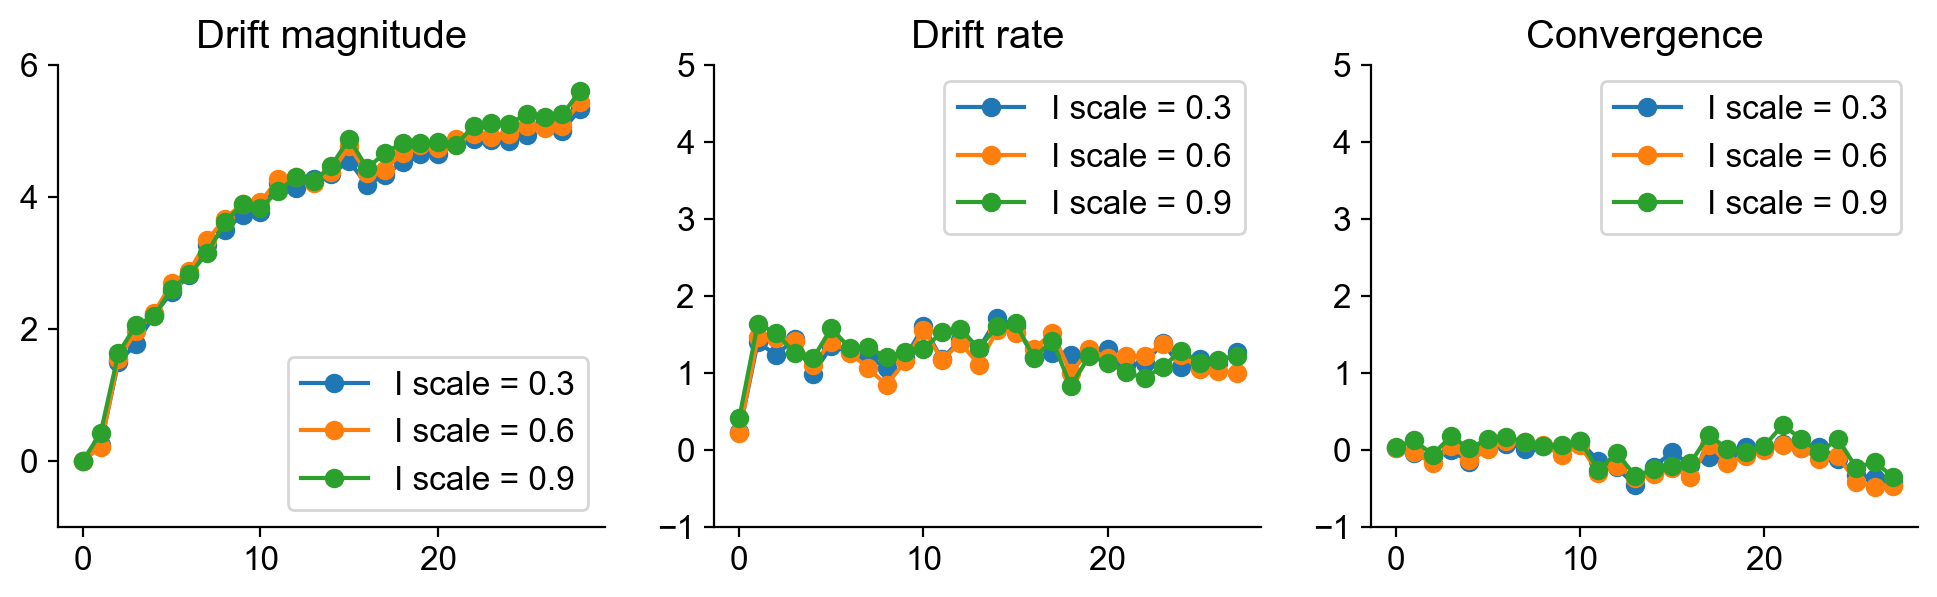

In [ ]:
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200)
axs[0].plot(np.nanmean(drift_mag_1, axis=1), marker='o', label="I scale = 0.3")
axs[0].plot(np.nanmean(drift_mag_2, axis=1), marker='o', label="I scale = 0.6")
axs[0].plot(np.nanmean(drift_mag_3, axis=1), marker='o', label="I scale = 0.9")
axs[0].set_title("Drift magnitude")
axs[0].legend()
axs[0].set_ylim([-1, 6])


axs[1].plot(np.nanmean(drift_rate_1, axis=1), marker='o', label="I scale = 0.3")
axs[1].plot(np.nanmean(drift_rate_2, axis=1), marker='o', label="I scale = 0.6")
axs[1].plot(np.nanmean(drift_rate_3, axis=1), marker='o', label="I scale = 0.9")
axs[1].set_title("Drift rate")
axs[1].legend()
axs[1].set_ylim([-1, 5])

axs[2].plot(np.nanmean(convergence_1, axis=1), marker='o', label="I scale = 0.3")
axs[2].plot(np.nanmean(convergence_2, axis=1), marker='o', label="I scale = 0.6")
axs[2].plot(np.nanmean(convergence_3, axis=1), marker='o', label="I scale = 0.9")
axs[2].set_title("Convergence")
axs[2].legend()
axs[2].set_ylim([-1, 5])


In [ ]:
activity_1 = net_inh_1.estimate_activity_at_day(90, 10)
activity_2 = net_inh_2.estimate_activity_at_day(90, 10)
activity_3 = net_inh_3.estimate_activity_at_day(90, 10)

Text(0.5, 1.0, 'Estimated activity at day 90')

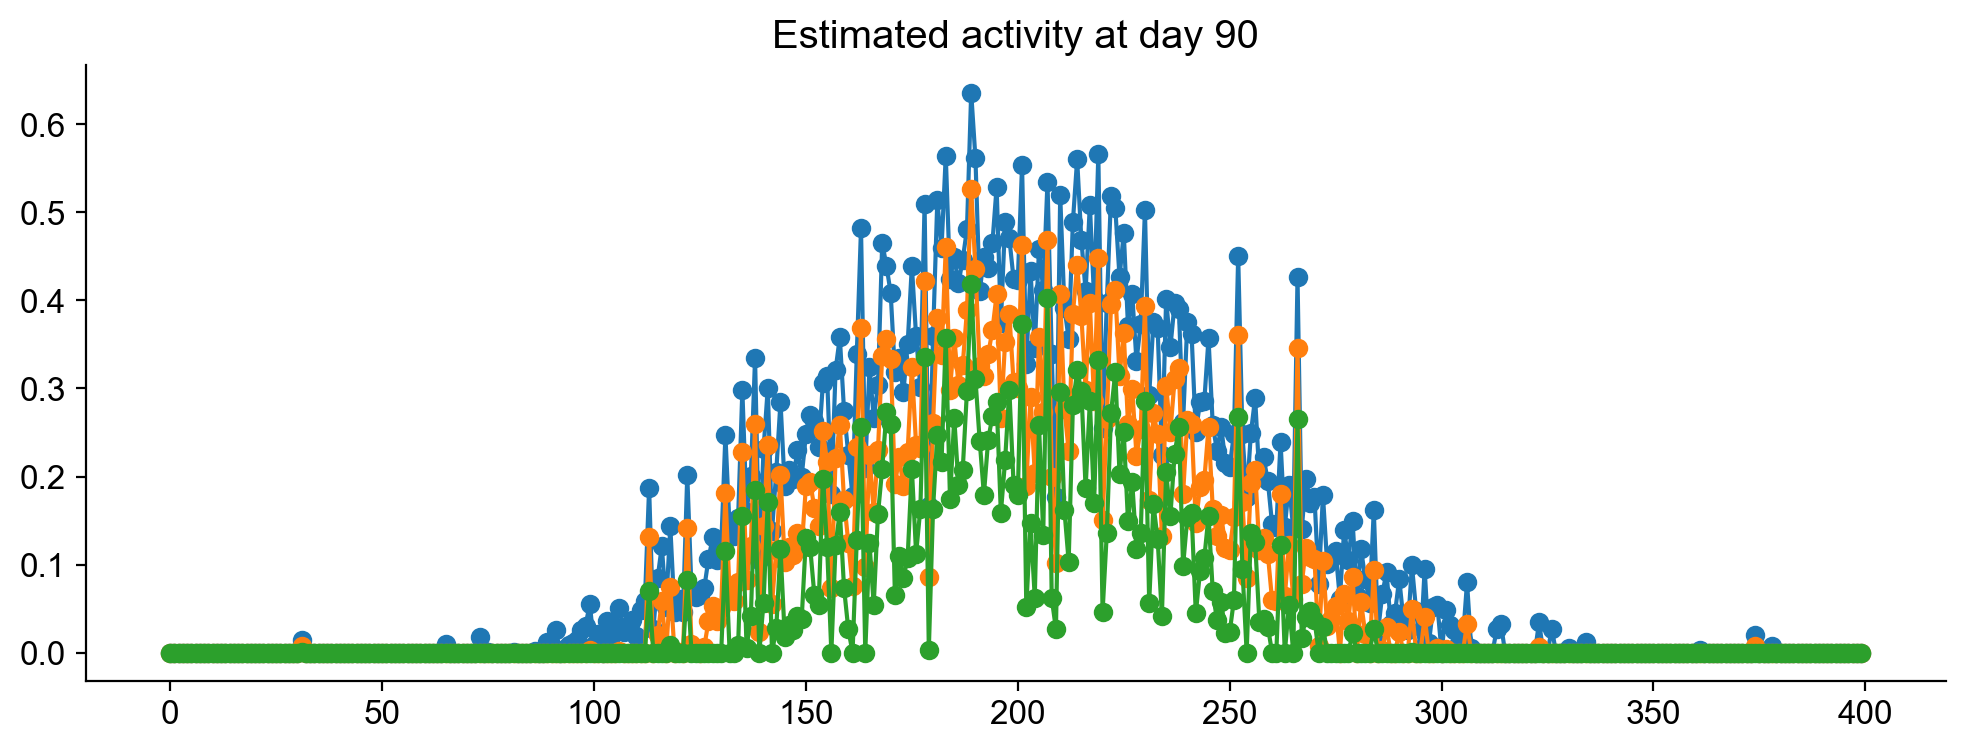

In [ ]:
activity_1 = activity_1[0]
activity_2 = activity_2[0]
activity_3 = activity_3[0]

plt.figure(dpi=200, figsize=(12,4))
plt.plot(activity_1, marker='o', label="I scale = 0.3")
plt.plot(activity_2, marker='o', label="I scale = 0.6")
plt.plot(activity_3, marker='o', label="I scale = 0.9")
plt.title("Estimated activity at day 90") 

/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_74866/3805885358.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_74866/3805885358.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_74866/3805885358.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[2].legend()


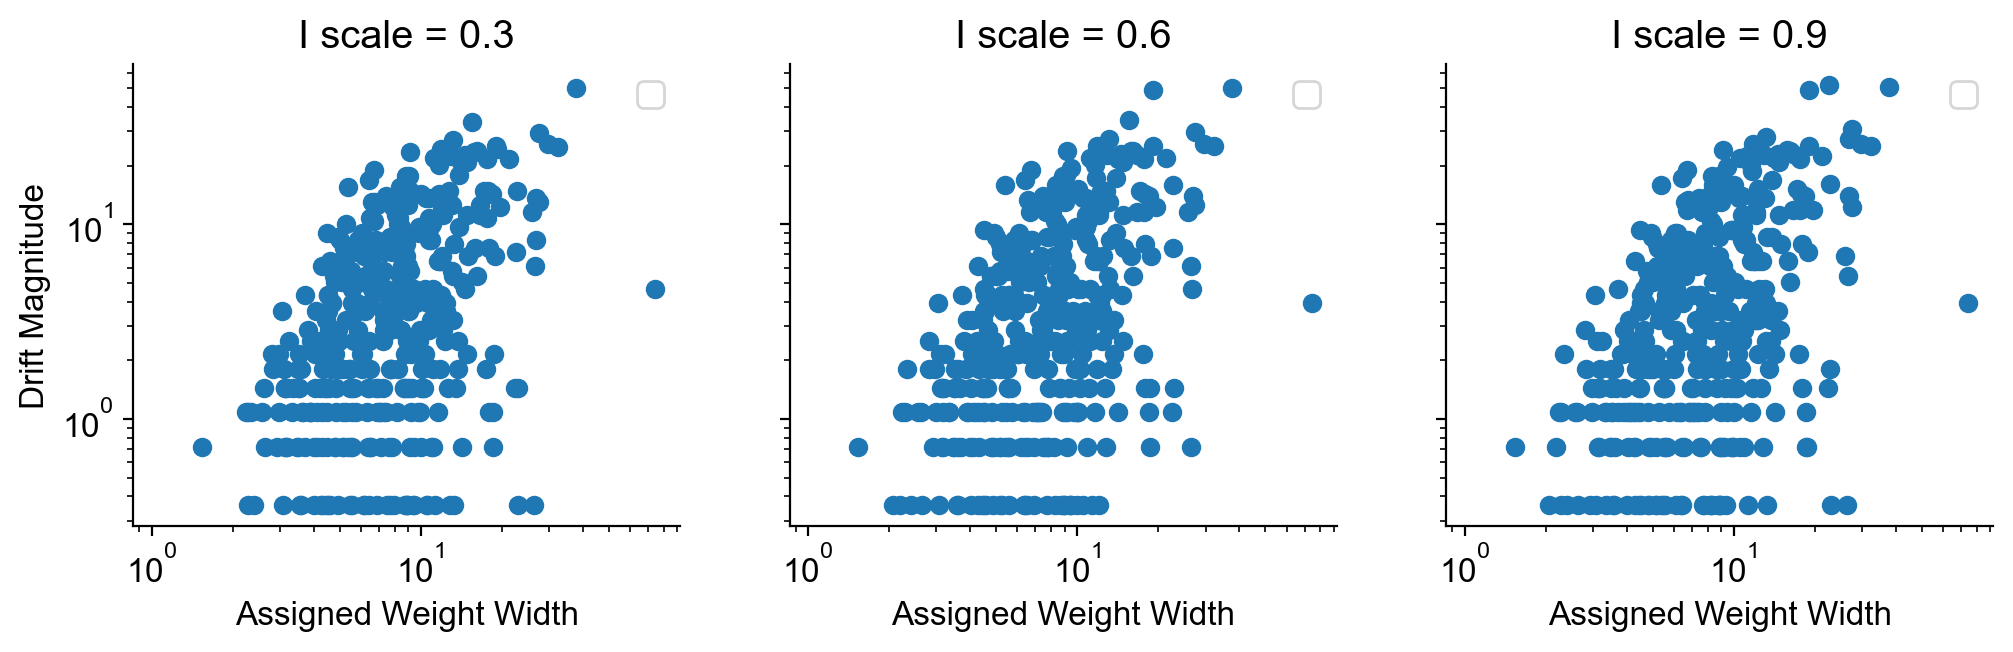

In [ ]:
# plot drift magnitude vs assigned weight width (vars_ef)
 
fig, axs = plt.subplots(1,3, figsize=(12, 3), dpi=200, sharex=True, sharey=True)

axs[0].scatter(net_inh_1.vars_ef, drift_mag_1[-1])
axs[0].set_xlabel("Assigned Weight Width")
axs[0].set_ylabel("Drift Magnitude")
axs[0].set_title("I scale = 0.3")
axs[0].legend()
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[1].scatter(net_inh_2.vars_ef, drift_mag_2[-1])
axs[1].set_xlabel("Assigned Weight Width")
axs[1].set_title("I scale = 0.6")
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[2].scatter(net_inh_3.vars_ef, drift_mag_3[-1])
axs[2].set_xlabel("Assigned Weight Width") 
axs[2].set_title("I scale = 0.9")
axs[2].legend()
axs[2].set_xscale('log')
axs[2].set_yscale('log')




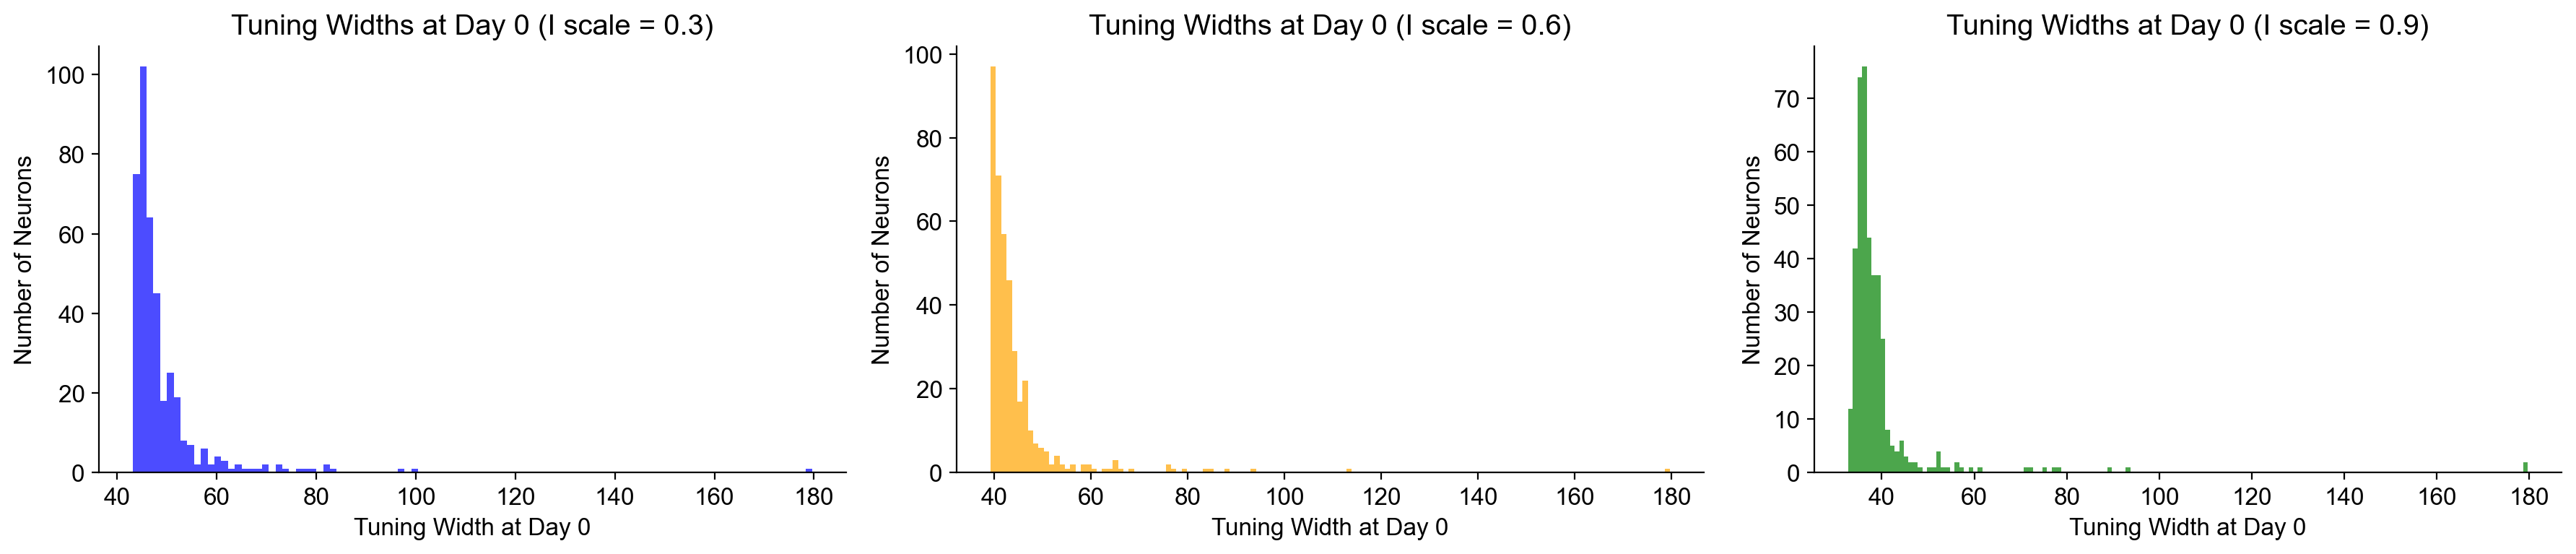

In [ ]:
_ ,initial_tuning_widths_1 = net_inh_1.estimate_tuning_curves_at_day(0)
_, initial_tuning_widths_2 = net_inh_2.estimate_tuning_curves_at_day(0)
_, initial_tuning_widths_3 = net_inh_3.estimate_tuning_curves_at_day(0)

fig, axs = plt.subplots(1, 3, figsize=(18, 4), dpi=200)
axs[0].hist(initial_tuning_widths_1, bins='fd', color='blue', alpha=0.7)
axs[0].set_title('Tuning Widths at Day 0 (I scale = 0.3)')
axs[0].set_xlabel('Tuning Width at Day 0')
axs[0].set_ylabel('Number of Neurons')

axs[1].hist(initial_tuning_widths_2, bins='fd', color='orange', alpha=0.7)
axs[1].set_title('Tuning Widths at Day 0 (I scale = 0.6)')
axs[1].set_xlabel('Tuning Width at Day 0')  
axs[1].set_ylabel('Number of Neurons')

axs[2].hist(initial_tuning_widths_3, bins='fd', color='green', alpha=0.7)
axs[2].set_title('Tuning Widths at Day 0 (I scale = 0.9)')
axs[2].set_xlabel('Tuning Width at Day 0')  
axs[2].set_ylabel('Number of Neurons')
plt.tight_layout()
plt.show()

/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_74866/2787571148.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


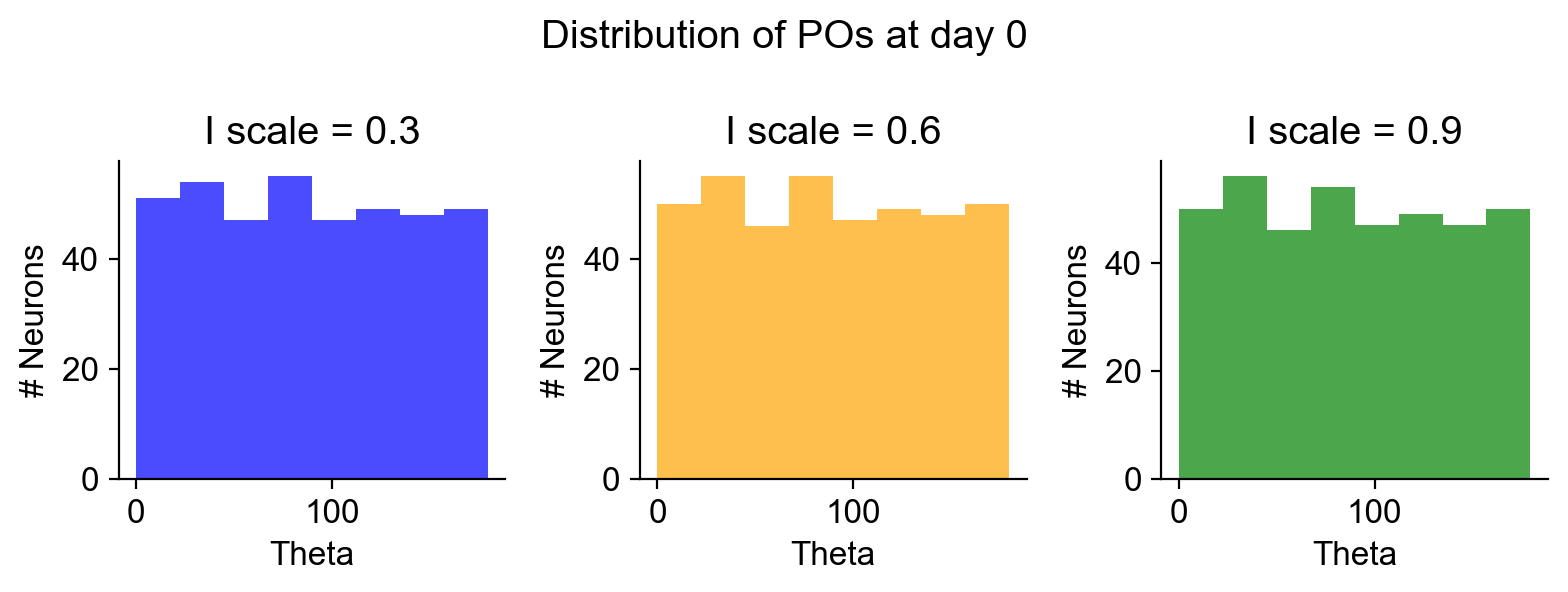

In [ ]:
# Distribution of POs at day 0

fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=200)
axs[0].hist(net_inh_1.POs[0], bins='fd', color='blue', alpha=0.7)
axs[0].set_title('I scale = 0.3')
axs[0].set_xlabel('Theta')
axs[0].set_ylabel('# Neurons')

axs[1].hist(net_inh_2.POs[0], bins='fd', color='orange', alpha=0.7)
axs[1].set_title('I scale = 0.6')
axs[1].set_xlabel('Theta')
axs[1].set_ylabel('# Neurons')

axs[2].hist(net_inh_3.POs[0], bins='fd', color='green', alpha=0.7)
axs[2].set_title('I scale = 0.9')
axs[2].set_xlabel('Theta')
axs[2].set_ylabel('# Neurons')
fig.suptitle("Distribution of POs at day 0")
fig.tight_layout()
fig.show()

/var/folders/g6/7nyb4bzj60n8q754q7qp7z200000gn/T/ipykernel_74866/3147703226.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


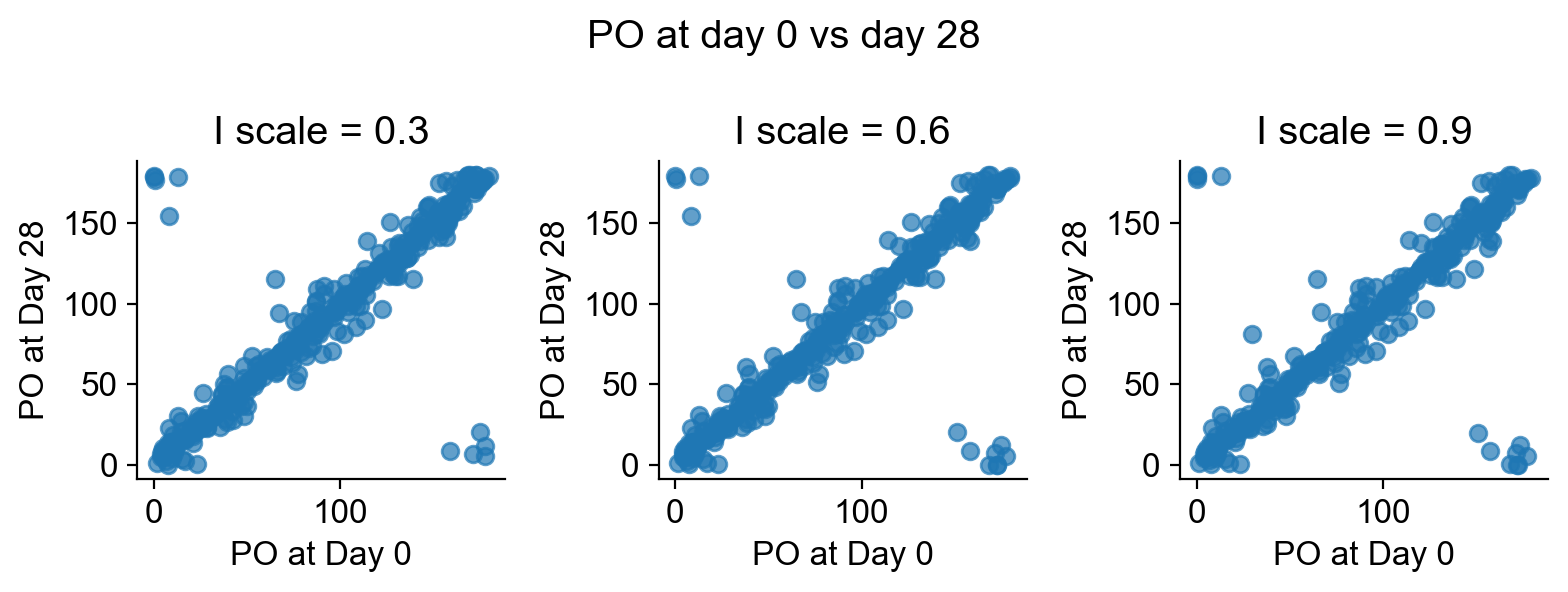

In [ ]:
# Scatter of POs at day 0 vs day 28
fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=200)

axs[0].scatter(net_inh_1.POs[0], net_inh_1.POs[28], alpha=0.7)
axs[0].set_title('I scale = 0.3')
axs[0].set_xlabel('PO at Day 0')
axs[0].set_ylabel('PO at Day 28')

axs[1].scatter(net_inh_2.POs[0], net_inh_2.POs[28], alpha=0.7)
axs[1].set_title('I scale = 0.6')
axs[1].set_xlabel('PO at Day 0')
axs[1].set_ylabel('PO at Day 28')

axs[2].scatter(net_inh_3.POs[0], net_inh_3.POs[28], alpha=0.7)
axs[2].set_title('I scale = 0.9')
axs[2].set_xlabel('PO at Day 0')
axs[2].set_ylabel('PO at Day 28')
fig.suptitle("PO at day 0 vs day 28")
fig.tight_layout()
fig.show()

/Users/divyansh/Library/CloudStorage/GoogleDrive-divyanshg1207@gmail.com/My Drive/Course Stuff/PhD/Projects | PhD/sensory drift/drift_model_2026/scripts/full_network/../../src/baseline_network.py:659: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


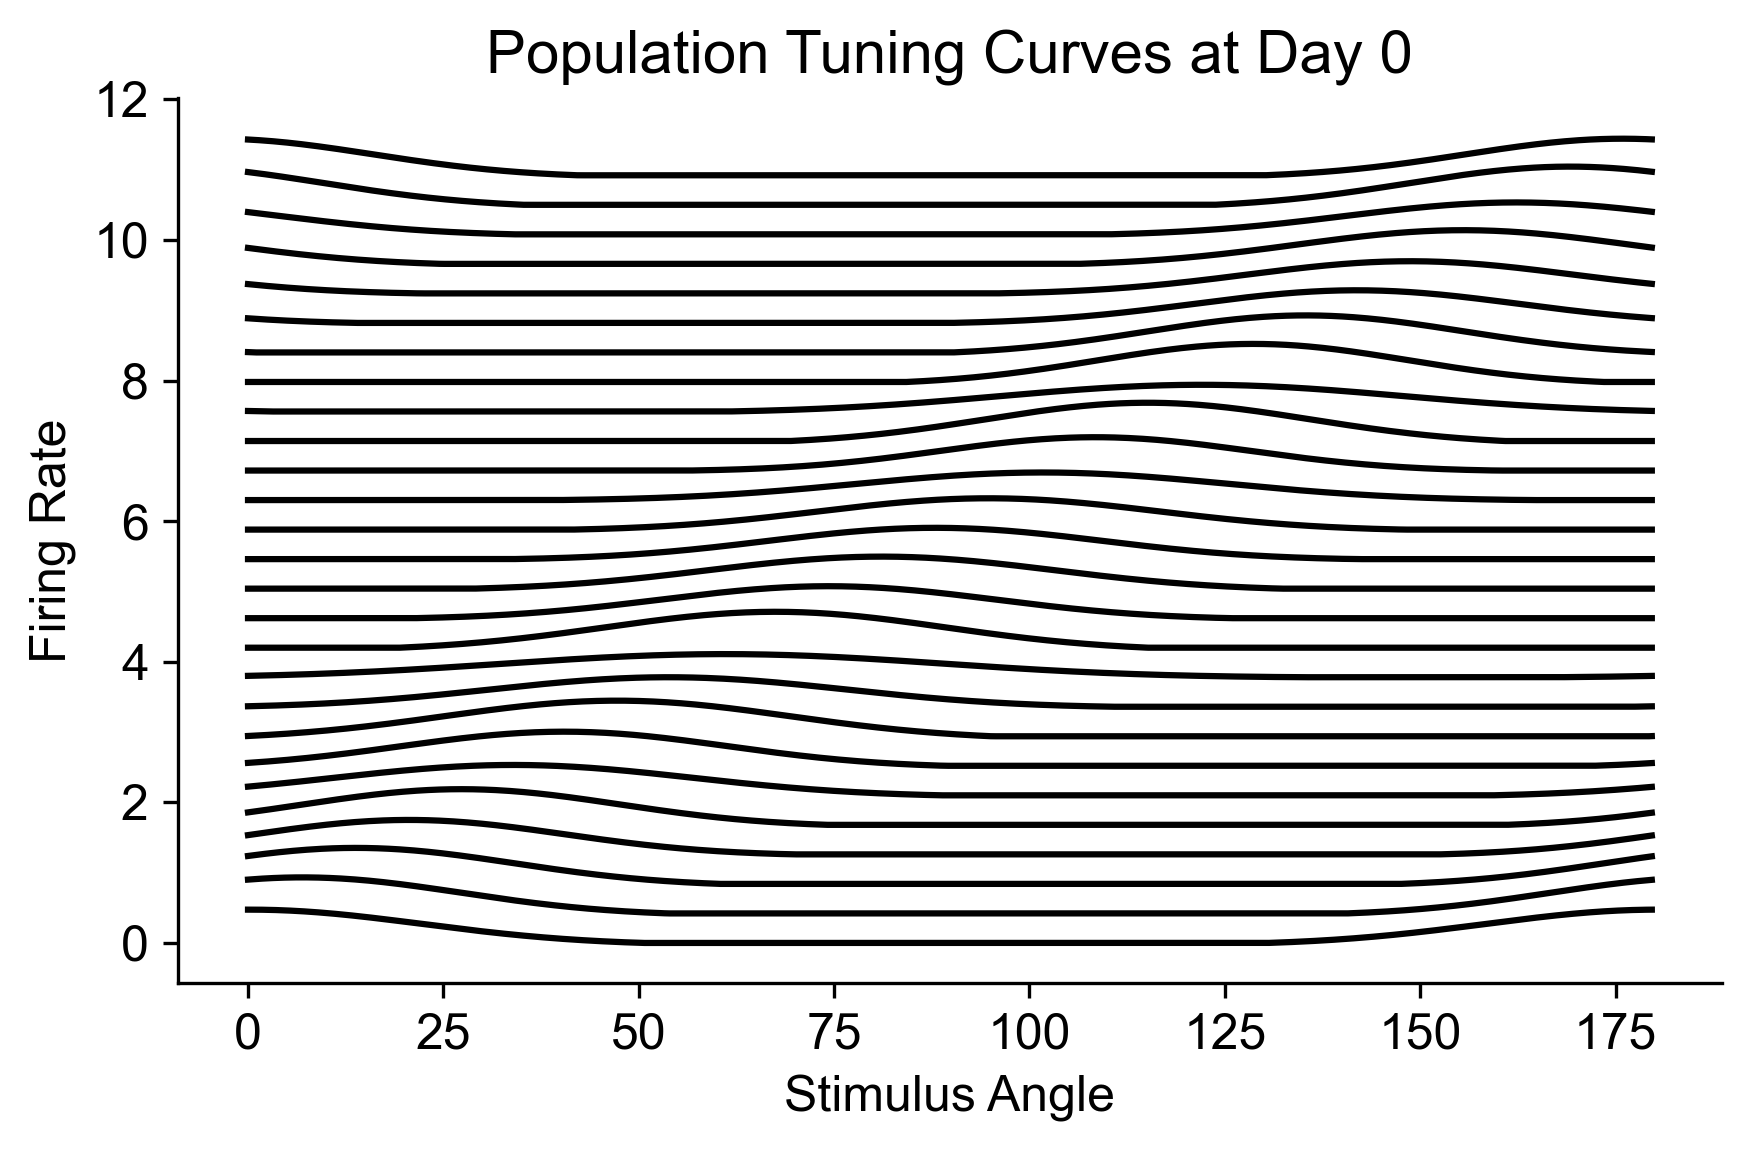

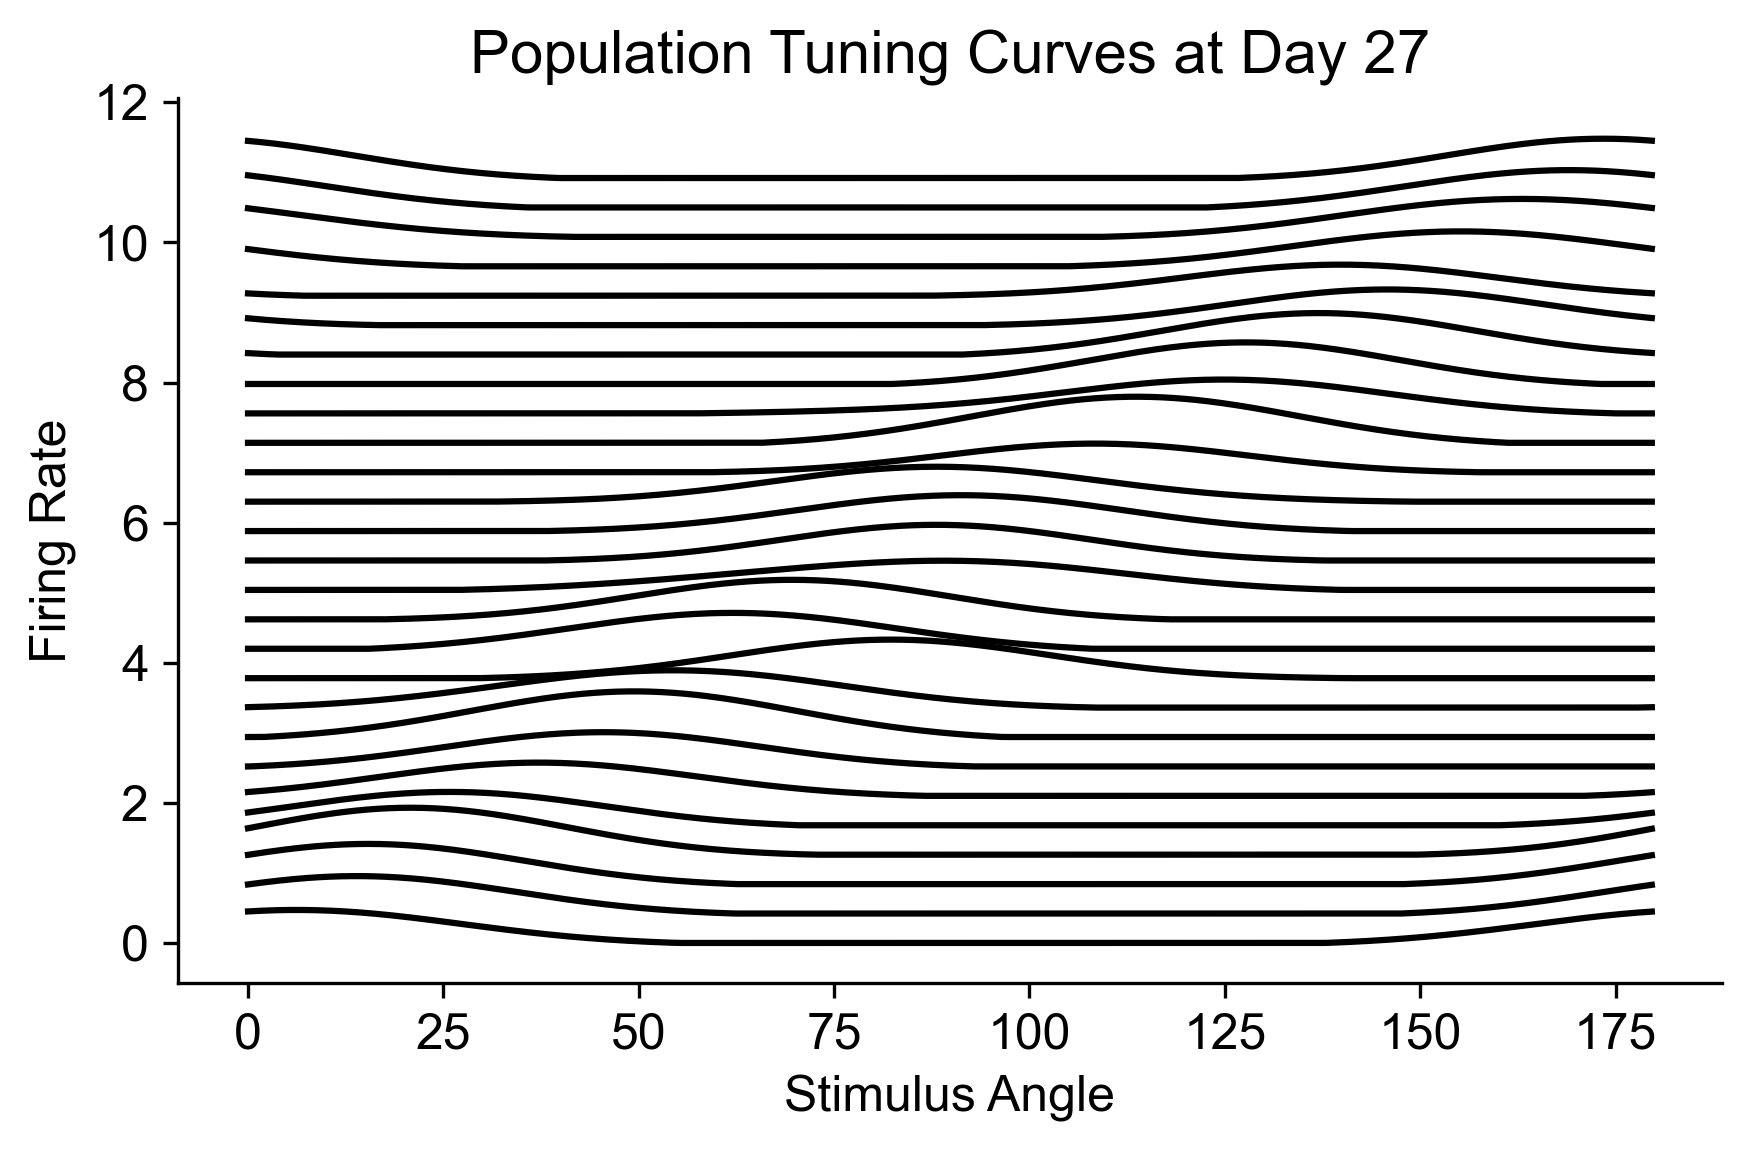

In [ ]:
# Plot tuning curves at day 0 and day 28 for the 3 inhibition levels

# fig, axs = plt.subplots(3, 2, figsize=(12, 12), dpi=200)
net_inh_1.plot_population_tuning_curves(0)
net_inh_1.plot_population_tuning_curves(27)

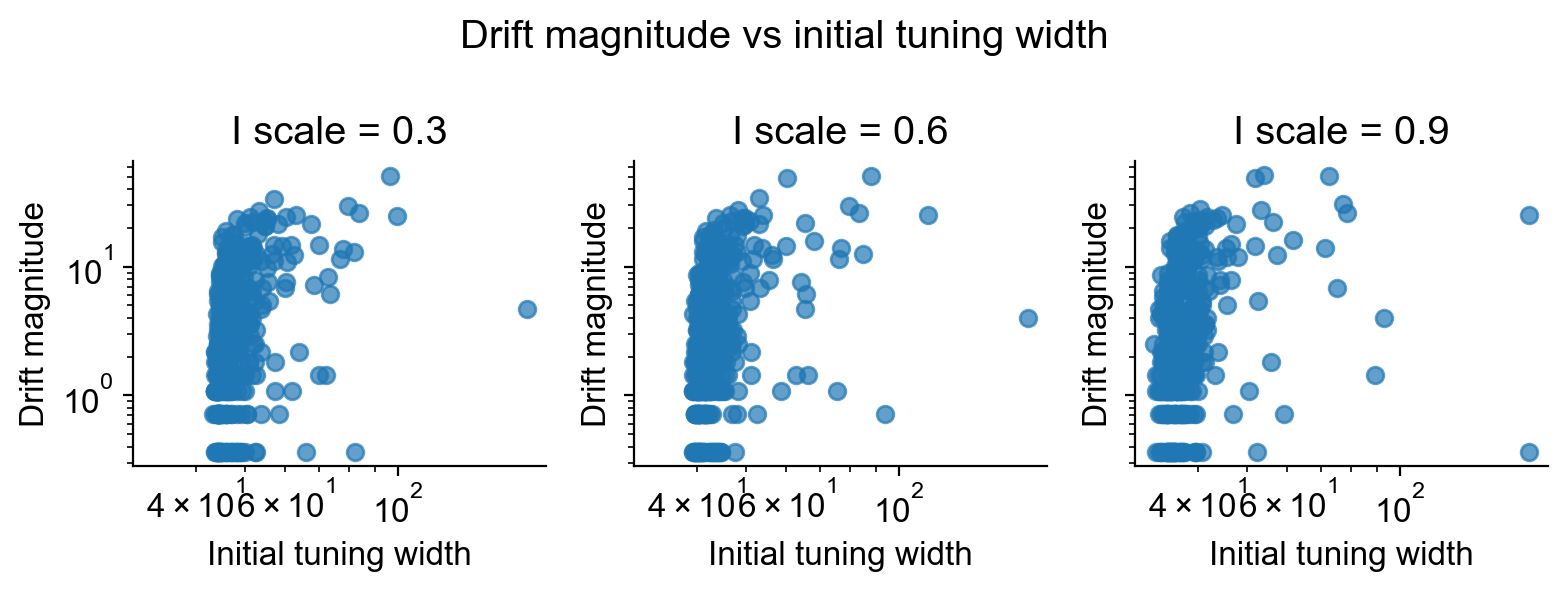

In [ ]:
# Plot drift magnitude vs initial tuning width
_, initial_tuning_widths_1 = net_inh_1.estimate_tuning_curves_at_day(0)
_, initial_tuning_widths_2 = net_inh_2.estimate_tuning_curves_at_day(0)
_, initial_tuning_widths_3 = net_inh_3.estimate_tuning_curves_at_day(0)

fig, axs = plt.subplots(1, 3, figsize=(8, 3), dpi=200, sharex= True, sharey=True)
axs[0].scatter(initial_tuning_widths_1, drift_mag_1[-1], alpha=0.7)
axs[0].set_title('I scale = 0.3')
axs[0].set_xlabel('Initial tuning width')
axs[0].set_ylabel('Drift magnitude')
axs[0].set_xscale('log')
axs[0].set_yscale('log')

axs[1].scatter(initial_tuning_widths_2, drift_mag_2[-1], alpha=0.7)
axs[1].set_title('I scale = 0.6')
axs[1].set_xlabel('Initial tuning width')
axs[1].set_ylabel('Drift magnitude')

axs[2].scatter(initial_tuning_widths_3, drift_mag_3[-1], alpha=0.7)
axs[2].set_title('I scale = 0.9')
axs[2].set_xlabel('Initial tuning width')
axs[2].set_ylabel('Drift magnitude')
fig.suptitle("Drift magnitude vs initial tuning width")
fig.tight_layout()
